In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

LOG_PATH = '../results/sft_gsm8k/r32/train_log.csv'
OUT_PATH = '../figures/sft_training_curve.png'

In [2]:
df = pd.read_csv(LOG_PATH)
df = df[df['step'] != 'step']  # убираем дублированный заголовок
df = df.apply(pd.to_numeric, errors='coerce')

train = df[df['loss'].notna()][['step', 'loss', 'learning_rate']].copy()
evals = df[df['eval_loss'].notna()][['step', 'eval_loss']].copy()

print(f'Train steps: {len(train)},  Eval points: {len(evals)}')
print(evals)

Train steps: 264,  Eval points: 6
     step  eval_loss
45    439   0.274205
90    878   0.266585
135  1317   0.275271
180  1756   0.309888
225  2195   0.377607
270  2634   0.447280


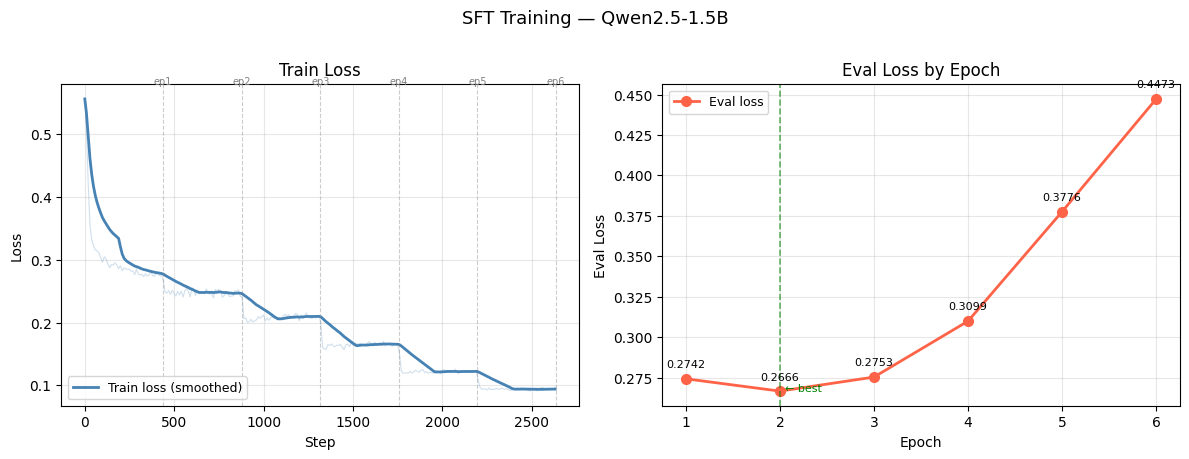

Saved to ../figures/sft_training_curve.png


In [3]:
SMOOTH = 20  # скользящее среднее для train loss

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('SFT Training — Qwen2.5-1.5B', fontsize=13, y=1.01)

# ── Левый: Train Loss ──────────────────────────────────────────
ax1.plot(train['step'], train['loss'], alpha=0.25, color='steelblue', linewidth=0.8)
ax1.plot(
    train['step'],
    train['loss'].rolling(SMOOTH, min_periods=1).mean(),
    color='steelblue', linewidth=2, label='Train loss (smoothed)'
)

# Вертикальные линии на границах эпох
for _, row in evals.iterrows():
    ax1.axvline(row['step'], color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
    ax1.text(row['step'], ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 0.6,
             f"ep{int(row['step']//439)}",
             fontsize=7, ha='center', color='gray')

ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('Train Loss')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── Правый: Eval Loss по эпохам ────────────────────────────────
epochs = range(1, len(evals) + 1)
ax2.plot(list(epochs), evals['eval_loss'].values, 'o-',
         color='tomato', linewidth=2, markersize=7, label='Eval loss')

# Подписи значений
for ep, (_, row) in zip(epochs, evals.iterrows()):
    ax2.annotate(
        f"{row['eval_loss']:.4f}",
        (ep, row['eval_loss']),
        textcoords='offset points', xytext=(0, 8),
        ha='center', fontsize=8
    )

# Отметить лучшую эпоху
best_ep = evals['eval_loss'].idxmin()
best_val = evals.loc[best_ep, 'eval_loss']
best_epoch_num = list(evals.index).index(best_ep) + 1
ax2.axvline(best_epoch_num, color='green', linestyle='--', alpha=0.6, linewidth=1.2)
ax2.text(best_epoch_num + 0.05, best_val, '← best', color='green', fontsize=8)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Eval Loss')
ax2.set_title('Eval Loss by Epoch')
ax2.set_xticks(list(epochs))
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {OUT_PATH}')